# Physics task results

Loads a single `*.run.json` from `run_results/` and plots accuracy across ramp steepness and number of configured goals.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt

import results_utils

RUN_FILE = Path("run_results/AnimalAI_physics_task_control-run_id_Run_1_google_gemini-3-flash-preview.run.json")

In [30]:
df = results_utils.load_run(RUN_FILE)
df.head()

,ramp_height,main,ramp_goal,wall,n_goals,correct,response,input_tokens,output_tokens,latency_ms,model,run_file,trial_id
0,-10,absent,absent,absent,0,1.0,"""{\""reasoning\"": \""Upon examining the image, t...",1281,66,5319,google/gemini-3-flash-preview,AnimalAI_physics_task_control-run_id_Run_1_goo...,trial_ramp_-10_main_absent_ramp_absent_wall_ab...
1,-10,absent,absent,goodgoal,1,1.0,"""{\""reasoning\"": \""Upon inspecting the image, ...",1281,75,9050,google/gemini-3-flash-preview,AnimalAI_physics_task_control-run_id_Run_1_goo...,trial_ramp_-10_main_absent_ramp_absent_wall_go...
2,-10,absent,absent,goodgoalmulti,1,0.0,"""{\""reasoning\"": \""The image shows a yellow sp...",1281,78,4650,google/gemini-3-flash-preview,AnimalAI_physics_task_control-run_id_Run_1_goo...,trial_ramp_-10_main_absent_ramp_absent_wall_go...
3,-10,absent,goodgoal,absent,1,0.0,"""{\""reasoning\"": \""The image shows a green sph...",1281,122,50630,google/gemini-3-flash-preview,AnimalAI_physics_task_control-run_id_Run_1_goo...,trial_ramp_-10_main_absent_ramp_goodgoal_wall_...
4,-10,absent,goodgoal,goodgoal,2,0.0,"""{\""reasoning\"": \""The image shows a green sph...",1281,79,4202,google/gemini-3-flash-preview,AnimalAI_physics_task_control-run_id_Run_1_goo...,trial_ramp_-10_main_absent_ramp_goodgoal_wall_...


In [31]:
overall = results_utils.overall_accuracy(df)
n_correct = int(df["correct"].sum())
print(f"Overall accuracy: {overall:.2%} ({n_correct}/{len(df)})")

Overall accuracy: 31.40% (65/207)


## Accuracy vs ramp steepness

In [32]:
acc_by_ramp = results_utils.accuracy_by_ramp(df)
acc_by_ramp

,ramp_height,accuracy,n_trials
0,-10,0.333333,27
1,-8,0.333333,27
2,-6,0.222222,27
3,-4,0.259259,27
4,-2,0.259259,27
5,0,0.074074,27
6,2,0.222222,9
7,4,0.555556,9
8,6,0.777778,9
9,8,0.555556,9


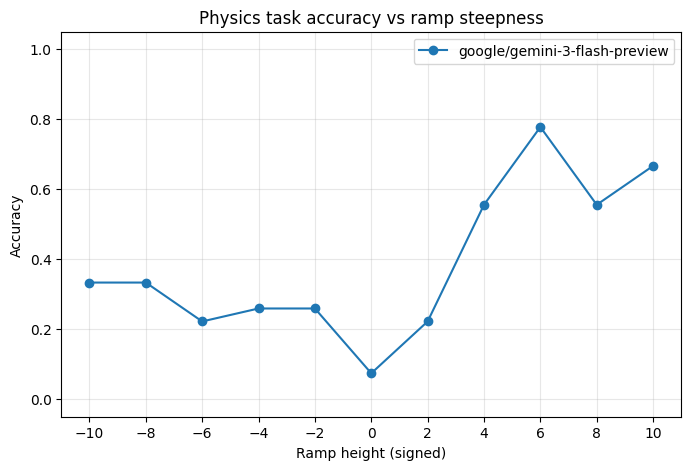

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, group in df.groupby("model"):
    by_ramp = results_utils.accuracy_by_ramp(group)
    ax.plot(by_ramp["ramp_height"], by_ramp["accuracy"], marker="o", label=model)

ax.set_xticks(sorted(df["ramp_height"].unique()))
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Ramp height (signed)")
ax.set_ylabel("Accuracy")
ax.set_title("Physics task accuracy vs ramp steepness")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Accuracy vs number of goals

Number of goals is the configured count summed across the main, ramp, and wall positions (0-3).

In [34]:
acc_by_goals = results_utils.accuracy_by_n_goals(df)
acc_by_goals

,n_goals,accuracy,n_trials
0,0,1.000000,11
1,1,0.571429,56
2,2,0.228261,92
3,3,0.020833,48


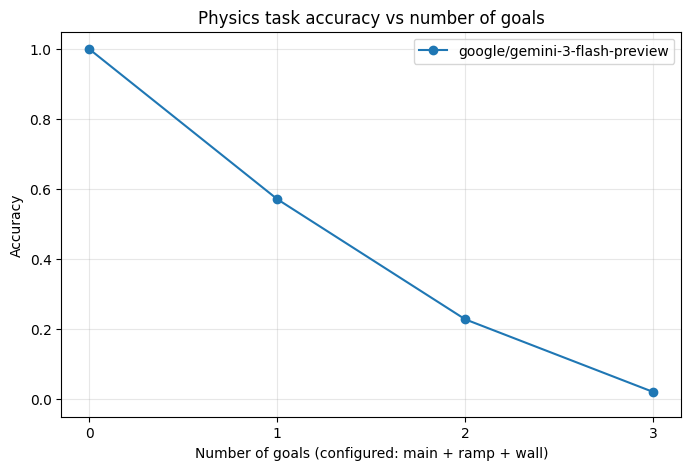

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, group in df.groupby("model"):
    by_goals = results_utils.accuracy_by_n_goals(group)
    ax.plot(by_goals["n_goals"], by_goals["accuracy"], marker="o", label=model)

ax.set_xticks(sorted(df["n_goals"].unique()))
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Number of goals (configured: main + ramp + wall)")
ax.set_ylabel("Accuracy")
ax.set_title("Physics task accuracy vs number of goals")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# test file

In [36]:
RUN_FILE_2 = Path("run_results/AnimalAI_physics_task-run_id_Run_1_google_gemini-3-flash-preview.run.json")

In [37]:
df_2 = results_utils.load_run(RUN_FILE_2)
df_2.head()

,ramp_height,main,ramp_goal,wall,n_goals,correct,response,input_tokens,output_tokens,latency_ms,model,run_file,trial_id
0,10,absent,goodgoal,absent,1,1.0,"""{\""reasoning\"": \""The image shows a green sph...",1281,90,7454,google/gemini-3-flash-preview,AnimalAI_physics_task-run_id_Run_1_google_gemi...,trial_ramp_10_main_absent_ramp_goodgoal_wall_a...
1,10,absent,goodgoal,goodgoal,2,1.0,"""{\""reasoning\"": \""The image shows a green sph...",1281,119,19976,google/gemini-3-flash-preview,AnimalAI_physics_task-run_id_Run_1_google_gemi...,trial_ramp_10_main_absent_ramp_goodgoal_wall_g...
2,10,absent,goodgoal,goodgoalmulti,2,1.0,"""{\""reasoning\"": \""The green sphere (reward) i...",1281,74,6540,google/gemini-3-flash-preview,AnimalAI_physics_task-run_id_Run_1_google_gemi...,trial_ramp_10_main_absent_ramp_goodgoal_wall_g...
3,10,absent,goodgoalmulti,absent,1,0.0,"""{\""reasoning\"": \""Upon a close examination of...",1281,125,27711,google/gemini-3-flash-preview,AnimalAI_physics_task-run_id_Run_1_google_gemi...,trial_ramp_10_main_absent_ramp_goodgoalmulti_w...
4,10,absent,goodgoalmulti,goodgoal,2,1.0,"""{\""reasoning\"": \""The image shows a yellow sp...",1281,70,8112,google/gemini-3-flash-preview,AnimalAI_physics_task-run_id_Run_1_google_gemi...,trial_ramp_10_main_absent_ramp_goodgoalmulti_w...


In [38]:
overall = results_utils.overall_accuracy(df_2)
n_correct = int(df_2["correct"].sum())
print(f"Overall accuracy: {overall:.2%} ({n_correct}/{len(df_2)})")

Overall accuracy: 98.89% (89/90)


# accuracy vs ramp steepness

In [39]:
acc_by_ramp_2 = results_utils.accuracy_by_ramp(df_2)
acc_by_ramp_2

,ramp_height,accuracy,n_trials
0,2,1.000000,18
1,4,1.000000,18
2,6,1.000000,18
3,8,1.000000,18
4,10,0.944444,18


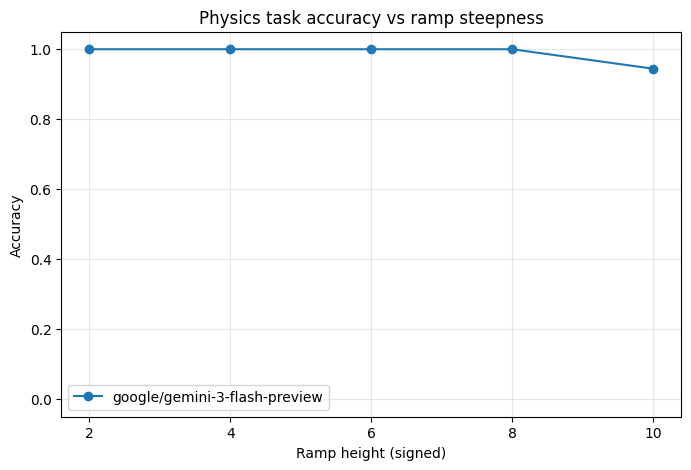

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, group in df_2.groupby("model"):
    by_ramp = results_utils.accuracy_by_ramp(group)
    ax.plot(by_ramp["ramp_height"], by_ramp["accuracy"], marker="o", label=model)

ax.set_xticks(sorted(df_2["ramp_height"].unique()))
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Ramp height (signed)")
ax.set_ylabel("Accuracy")
ax.set_title("Physics task accuracy vs ramp steepness")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# accuracy vs number of goals 

In [41]:
acc_by_goals_2 = results_utils.accuracy_by_n_goals(df_2)
acc_by_goals_2

,n_goals,accuracy,n_trials
0,1,0.9,10
1,2,1.0,40
2,3,1.0,40


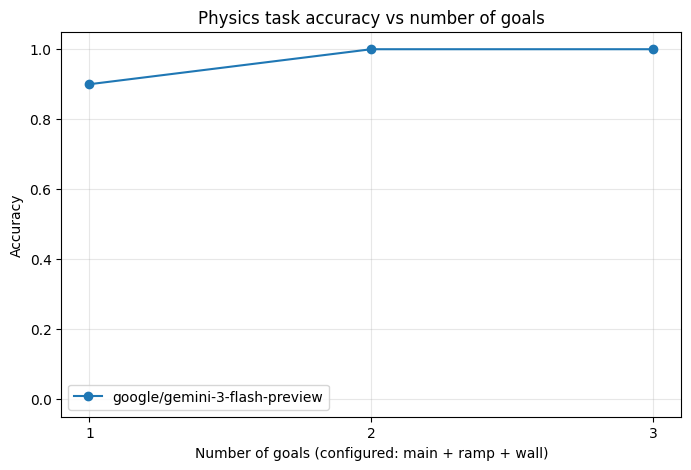

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, group in df_2.groupby("model"):
    by_goals = results_utils.accuracy_by_n_goals(group)
    ax.plot(by_goals["n_goals"], by_goals["accuracy"], marker="o", label=model)

ax.set_xticks(sorted(df_2["n_goals"].unique()))
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Number of goals (configured: main + ramp + wall)")
ax.set_ylabel("Accuracy")
ax.set_title("Physics task accuracy vs number of goals")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()